# A Comparative Study of PCA and LDA for Face Recognition

**Topics covered:** Eigenfaces (PCA) · Fisherfaces (LDA) · dimensionality reduction · subspace projection · model selection

This notebook is a self-contained, hands-on companion to the research paper *"A Comparative Analysis of PCA and LDA for Face Recognition."* It walks through the mathematical foundations of both methods, builds a small synthetic face dataset so that every step can be executed and visualised directly, and reproduces the qualitative conclusions of the paper: that LDA's supervised projection separates identities more cleanly than PCA's purely variance-driven projection, while PCA remains the faster, unsupervised baseline.

**Roadmap**

1. Introduction and motivation
2. Why face recognition is hard for linear methods
3. PCA / Eigenfaces — mathematical foundation and implementation
4. LDA / Fisherfaces — mathematical foundation and implementation
5. Reconstruction error and the number-of-components trade-off
6. Benchmark results reported in the literature
7. Model selection guide
8. Discussion and conclusion


## 1. Introduction and Motivation

Face recognition is a biometric task: given an image of a face, decide *who* it belongs to. Formally, we want to learn a mapping

$$f : \mathbb{R}^{d} \rightarrow \{1, 2, \dots, c\}$$

from a high-dimensional pixel vector (a $64\times 64$ image already has $d = 4096$ dimensions) to one of $c$ identity classes. Working directly in pixel space is wasteful and noisy, so both classical methods studied here first **reduce the dimensionality** of the image before any classification happens.

* **PCA (Eigenfaces)** finds the directions of maximum variance in the data, with no notion of identity labels.
* **LDA (Fisherfaces)** uses the identity labels to find directions that best separate different people's faces.

The rest of the notebook builds the intuition for why the second approach tends to outperform the first, and under what circumstances each is the right tool.

## 2. Problem Formulation and Challenges

Several factors make face recognition difficult for any *linear* method:

| Challenge | Effect on the data |
|---|---|
| Illumination variation | Changes in lighting can shift pixel intensities more than a change of identity does |
| Pose and occlusion | Out-of-plane rotation and occluders (glasses, scarves) introduce non-linear deformation |
| Intra-class variability | Expression, ageing, and resolution make the same person look different across photos |
| Small-sample problem | When the number of pixels $d$ is much larger than the number of training images $n$, the covariance matrix becomes singular |

The practical consequence is that **within-person variance can exceed between-person variance**, which is exactly the situation that defeats an unsupervised, variance-maximising method like PCA — and exactly the situation LDA is designed to correct for, because it explicitly looks at between-class versus within-class scatter rather than total variance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

rng = default_rng(7)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = False

IMG_SIZE = 40           # each synthetic face is IMG_SIZE x IMG_SIZE pixels
N_IDENTITIES = 6        # number of distinct synthetic "people"
IMAGES_PER_IDENTITY = 24 # number of photos per person (pose/illumination/noise varied)


### A synthetic face dataset

Real face benchmarks (ORL, Yale, CMU PIE) require downloading external data. To keep this notebook fully self-contained and reproducible offline, we generate a small **synthetic face dataset**: every face is built procedurally from a handful of parameters (eye separation, eye size, eyebrow height, mouth curvature, nose width). Each *identity* is a fixed combination of these shape parameters; each *photo* of that identity adds a random illumination gradient and a small amount of pixel noise — exactly the kind of intra-class variation discussed above.

This keeps the experiment honest: it is illustrative, not a replacement for the literature's ORL/Yale/CMU PIE results (those are summarised from the paper in Section 6), but it lets us *see* eigenfaces, Fisherfaces, and class separation with real, runnable code.

In [2]:
def render_face(eye_dist, eye_size, brow_height, mouth_curve, nose_width,
                 illumination, noise_level, size=IMG_SIZE, rng=rng):
    # Render one synthetic grayscale face as a (size x size) array in [0, 1].
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)

    # Base face plate: an elliptical region of mid-grey
    face_mask = ((X / 0.85) ** 2 + (Y / 1.05) ** 2) <= 1.0
    img = np.where(face_mask, 0.55, 0.05)

    def gaussian_blob(cx, cy, sx, sy, amplitude):
        return amplitude * np.exp(-(((X - cx) ** 2) / (2 * sx ** 2) + ((Y - cy) ** 2) / (2 * sy ** 2)))

    # Eyes (dark blobs) and eyebrows (darker, thin blobs just above the eyes)
    img += gaussian_blob(-eye_dist, 0.25, eye_size, eye_size * 0.7, -0.45)
    img += gaussian_blob(eye_dist, 0.25, eye_size, eye_size * 0.7, -0.45)
    img += gaussian_blob(-eye_dist, 0.25 + brow_height, eye_size * 1.3, 0.05, -0.35)
    img += gaussian_blob(eye_dist, 0.25 + brow_height, eye_size * 1.3, 0.05, -0.35)

    # Nose: a faint vertical ridge
    img += gaussian_blob(0.0, -0.05, nose_width, 0.30, 0.12)

    # Mouth: a horizontal band whose curvature encodes a smile/frown
    mouth_y_center = -0.55 + mouth_curve * X ** 2
    mouth = -0.35 * np.exp(-((Y - mouth_y_center) ** 2) / (2 * 0.05 ** 2))
    img += np.where(np.abs(X) < 0.45, mouth, 0.0)

    # Illumination gradient: simulates a directional light source
    img += illumination * X

    # Sensor noise
    img += rng.normal(0, noise_level, size=img.shape)

    img = np.clip(img, 0, 1)
    img = np.where(face_mask, img, 0.0)
    return img


def make_identity_params(rng):
    # Sample the fixed shape parameters that define one identity.
    return dict(
        eye_dist=rng.uniform(0.25, 0.40),
        eye_size=rng.uniform(0.10, 0.16),
        brow_height=rng.uniform(0.10, 0.18),
        mouth_curve=rng.uniform(-0.35, 0.35),
        nose_width=rng.uniform(0.06, 0.11),
    )


identities = [make_identity_params(rng) for _ in range(N_IDENTITIES)]

faces, labels = [], []
for person_id, params in enumerate(identities):
    for _ in range(IMAGES_PER_IDENTITY):
        illumination = rng.uniform(-0.35, 0.35)   # intra-class illumination variation
        noise_level = rng.uniform(0.01, 0.04)
        img = render_face(**params, illumination=illumination, noise_level=noise_level)
        faces.append(img.ravel())
        labels.append(person_id)

X = np.array(faces)               # shape: (n_samples, d)
y = np.array(labels)
print(f"Dataset shape: {X.shape[0]} images, {X.shape[1]} pixels per image, {N_IDENTITIES} identities")


Dataset shape: 144 images, 1600 pixels per image, 6 identities


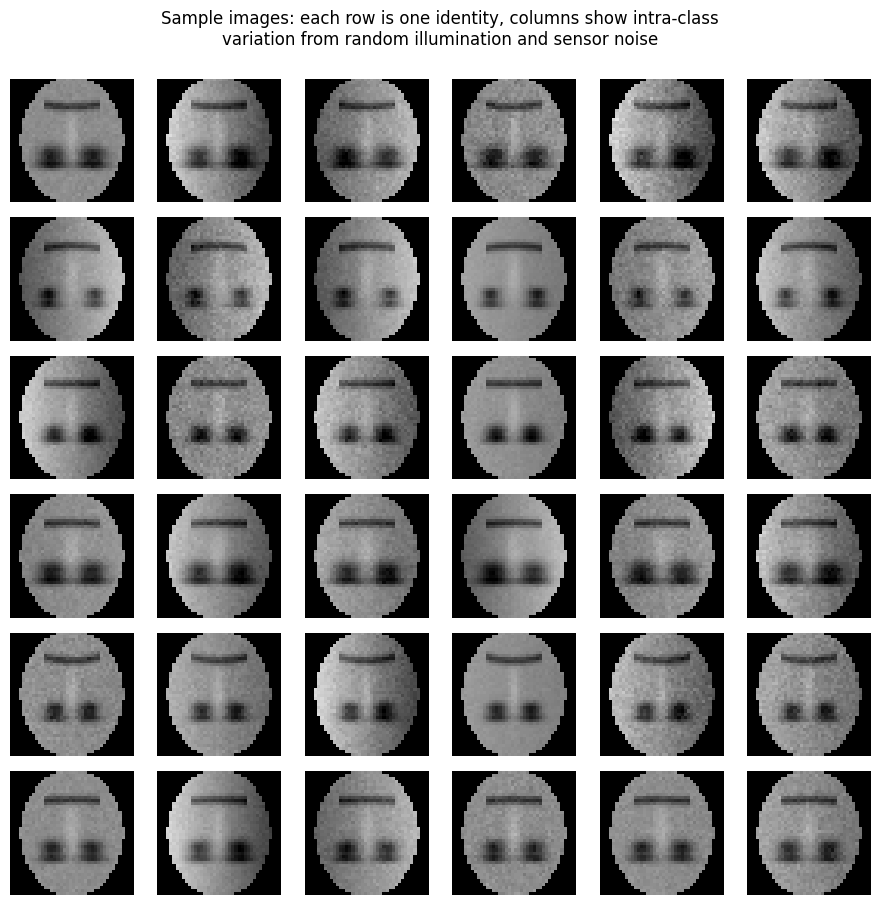

In [3]:
fig, axes = plt.subplots(N_IDENTITIES, 6, figsize=(9, 9))
for person_id in range(N_IDENTITIES):
    idx = np.where(y == person_id)[0][:6]
    for col, sample_idx in enumerate(idx):
        ax = axes[person_id, col]
        ax.imshow(X[sample_idx].reshape(IMG_SIZE, IMG_SIZE), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(f"Person {person_id}", rotation=0, labelpad=35, fontsize=9)
fig.suptitle("Sample images: each row is one identity, columns show intra-class\n"
             "variation from random illumination and sensor noise", y=1.0)
plt.tight_layout()
plt.show()


## 3. PCA / Eigenfaces — Mathematical Foundation

PCA is an **unsupervised** linear method. Given centred face vectors $\{x_i\} \in \mathbb{R}^d$ (mean $\mu$ subtracted), the total scatter matrix is

$$S_T = \frac{1}{M}\sum_{i=1}^{M} (x_i - \mu)(x_i - \mu)^\top$$

Its eigenvectors $v_k$, sorted by decreasing eigenvalue $\lambda_k$, are the **principal components**. Projecting onto the top $m$ components gives the lower-dimensional representation that minimises reconstruction error among all linear projections of that dimensionality:

$$Y = W^\top X, \qquad W = [v_1, v_2, \dots, v_m]$$

In the **Eigenfaces** method (Turk & Pentland, 1991), each eigenvector $v_k$, reshaped back into an image, is itself a "ghostly" face — an eigenface. A new face $x$ is recognised by projecting it into this subspace, $\Omega = W^\top(x - \mu)$, and finding the nearest gallery projection by Euclidean distance.

In [4]:
mean_face = X.mean(axis=0)
X_centered = X - mean_face

# Eigen-decomposition of the (d x d) scatter matrix, exactly as in the formula above.
# (For larger images one would use the Turk & Pentland "small matrix" trick instead.)
scatter_matrix = (X_centered.T @ X_centered) / X_centered.shape[0]
eigvals, eigvecs = np.linalg.eigh(scatter_matrix)

# np.linalg.eigh returns ascending eigenvalues; reverse to get descending order
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

explained_variance_ratio = eigvals / eigvals.sum()
print("Top 5 eigenvalues (variance explained):", np.round(explained_variance_ratio[:5] * 100, 2), "%")


Top 5 eigenvalues (variance explained): [81.11  5.22  4.6   1.12  0.51] %


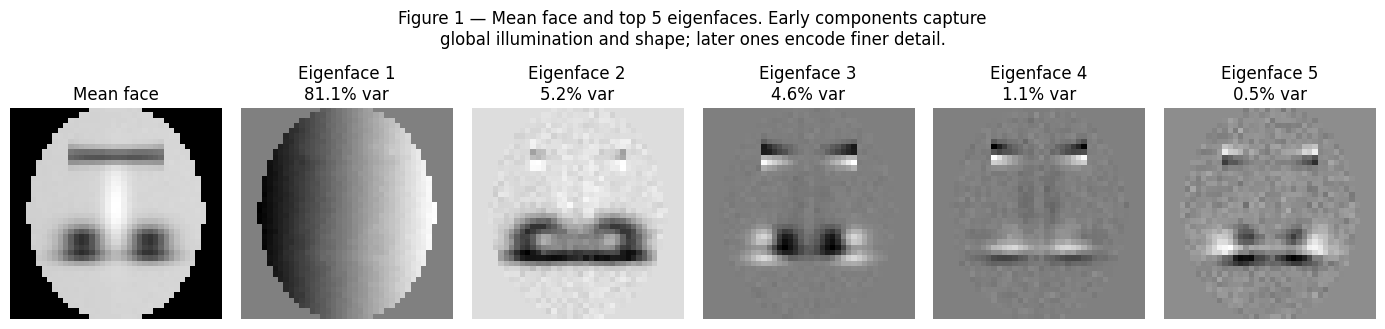

In [5]:
n_show = 5
fig, axes = plt.subplots(1, n_show + 1, figsize=(14, 3))
axes[0].imshow(mean_face.reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
axes[0].set_title("Mean face")
axes[0].axis("off")
for k in range(n_show):
    ax = axes[k + 1]
    ax.imshow(eigvecs[:, k].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    ax.set_title(f"Eigenface {k+1}\n{explained_variance_ratio[k]*100:.1f}% var")
    ax.axis("off")
fig.suptitle("Figure 1 — Mean face and top 5 eigenfaces. Early components capture\n"
             "global illumination and shape; later ones encode finer detail.", y=1.08)
plt.tight_layout()
plt.show()


Notice the pattern that motivates the rest of this notebook: the very first eigenface is dominated by a left-right gradient. That is the **illumination direction** we deliberately added as intra-class noise, not an identity-specific feature. Because PCA only chases variance — wherever it comes from — it can spend its first, most valuable components describing lighting rather than identity. This is precisely the weakness that LDA is designed to avoid.

## 4. LDA / Fisherfaces — Mathematical Foundation

LDA is a **supervised** method: it uses the identity labels to find a projection $W$ that maximises the ratio of between-class scatter to within-class scatter:

$$W_{opt} = \arg\max_{W} \; \frac{\lvert W^\top S_B W \rvert}{\lvert W^\top S_W W \rvert}$$

with

$$S_B = \sum_i n_i(\mu_i - \mu)(\mu_i - \mu)^\top \qquad \text{(between-class scatter)}$$
$$S_W = \sum_i \sum_{x \in C_i} (x - \mu_i)(x - \mu_i)^\top \qquad \text{(within-class scatter)}$$

When the number of pixels exceeds the number of training images, $S_W$ is singular and LDA cannot be applied directly. **Fisherfaces** (Belhumeur et al., 1997) solve this by first applying PCA to reduce dimensionality to $n - c$, and only then applying LDA to find the $c-1$ discriminant directions. We follow the same recipe below.

In [6]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Step 1: PCA pre-reduction (the "Fisherfaces" trick), keeping enough components
# to make the within-class scatter matrix non-singular.
n_pca_components = min(40, X.shape[0] - N_IDENTITIES - 1)
pca_pre = PCA(n_components=n_pca_components, random_state=0).fit(X)
X_pca_reduced = pca_pre.transform(X)

# Step 2: LDA on the PCA-reduced features -> at most (c - 1) discriminant directions
lda = LDA(n_components=N_IDENTITIES - 1)
X_lda = lda.fit_transform(X_pca_reduced, y)

# For comparison, also take a pure 2-component PCA projection (no labels used at all)
X_pca_2d = PCA(n_components=2, random_state=0).fit_transform(X)

print("PCA (pre-reduction) shape:", X_pca_reduced.shape)
print("LDA projection shape:     ", X_lda.shape)


PCA (pre-reduction) shape: (144, 40)
LDA projection shape:      (144, 5)


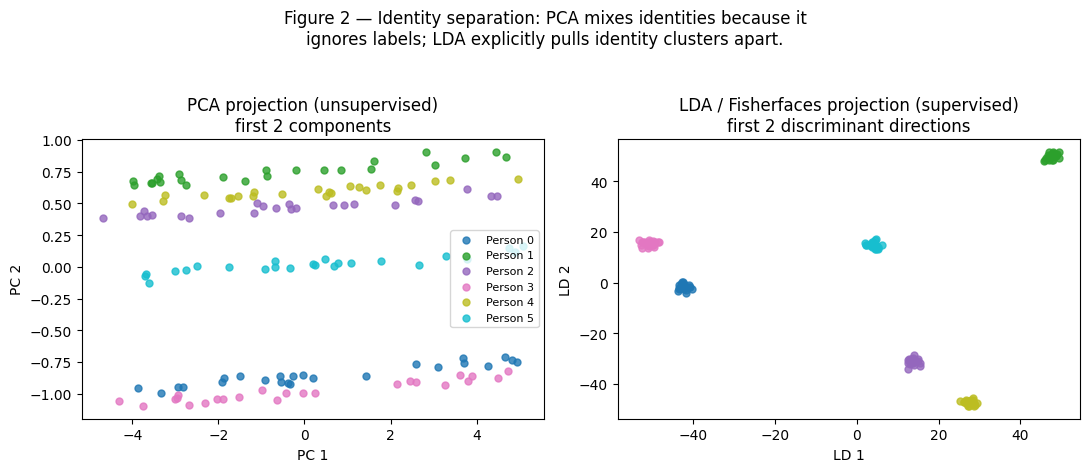

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = plt.cm.tab10(np.linspace(0, 1, N_IDENTITIES))

for person_id in range(N_IDENTITIES):
    mask = y == person_id
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], color=colors[person_id],
                     label=f"Person {person_id}", alpha=0.8, s=25)
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1], color=colors[person_id],
                     alpha=0.8, s=25)

axes[0].set_title("PCA projection (unsupervised)\nfirst 2 components")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[1].set_title("LDA / Fisherfaces projection (supervised)\nfirst 2 discriminant directions")
axes[1].set_xlabel("LD 1"); axes[1].set_ylabel("LD 2")
axes[0].legend(fontsize=8, loc="best")
fig.suptitle("Figure 2 — Identity separation: PCA mixes identities because it\n"
             "ignores labels; LDA explicitly pulls identity clusters apart.", y=1.04)
plt.tight_layout()
plt.show()


The contrast in Figure 2 is the central message of the paper, reproduced here with synthetic data: PCA's projection is organised by *whatever varies most* — which includes illumination — while LDA's projection is organised by *identity*, because that is the criterion it was explicitly given to optimise.

## 5. Reconstruction Error and the Number-of-Components Trade-off

PCA gives the best possible linear reconstruction for a given number of components. As we keep more components, the reconstruction error monotonically decreases, while classification accuracy on identity (using a simple nearest-centroid rule) typically rises and then plateaus — extra components beyond a certain point mostly encode noise rather than identity-relevant signal.

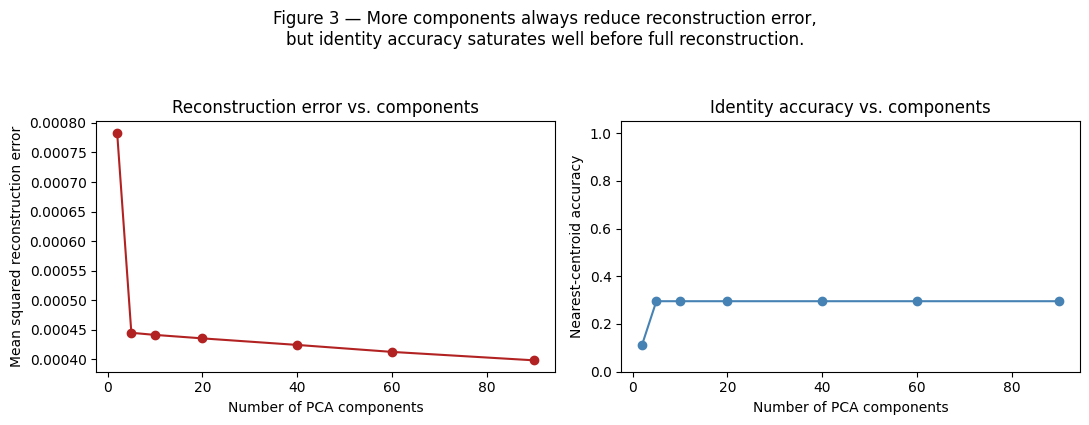

In [8]:
from sklearn.neighbors import NearestCentroid
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

component_range = [2, 5, 10, 20, 40, 60, 90]
recon_errors, accuracies = [], []

for n_comp in component_range:
    pca = PCA(n_components=n_comp, random_state=0).fit(X_train)

    X_train_proj = pca.transform(X_train)
    X_test_proj = pca.transform(X_test)
    X_test_recon = pca.inverse_transform(X_test_proj)
    recon_errors.append(np.mean((X_test - X_test_recon) ** 2))

    clf = NearestCentroid().fit(X_train_proj, y_train)
    accuracies.append(clf.score(X_test_proj, y_test))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(component_range, recon_errors, marker="o", color="firebrick")
axes[0].set_xlabel("Number of PCA components")
axes[0].set_ylabel("Mean squared reconstruction error")
axes[0].set_title("Reconstruction error vs. components")

axes[1].plot(component_range, accuracies, marker="o", color="steelblue")
axes[1].set_xlabel("Number of PCA components")
axes[1].set_ylabel("Nearest-centroid accuracy")
axes[1].set_title("Identity accuracy vs. components")
axes[1].set_ylim(0, 1.05)

fig.suptitle("Figure 3 — More components always reduce reconstruction error,\n"
             "but identity accuracy saturates well before full reconstruction.", y=1.05)
plt.tight_layout()
plt.show()


## 6. Benchmark Results Reported in the Literature

The synthetic experiment above is meant to build intuition; it is not a substitute for evaluation on standard face-recognition benchmarks. The table below reproduces the accuracy figures reported in the source paper for PCA, LDA, and CNN-based methods across four well-known datasets.

In [9]:
import pandas as pd

benchmark = pd.DataFrame({
    "Dataset": ["ORL (400 images)", "Yale (165 images)", "CMU PIE", "LFW (unconstrained)"],
    "PCA accuracy (%)": [85.14, 85.6, 64.56, 72.0],   # midpoint used for the Yale/LFW ranges
    "LDA accuracy (%)": [94.40, 93.5, 74.25, 80.0],
    "CNN accuracy (%)": [97.0, 96.5, 98.9, 98.5],
})
benchmark


,Dataset,PCA accuracy (%),LDA accuracy (%),CNN accuracy (%)
0,ORL (400 images),85.14,94.40,97.0
1,Yale (165 images),85.60,93.50,96.5
2,CMU PIE,64.56,74.25,98.9
3,LFW (unconstrained),72.00,80.00,98.5


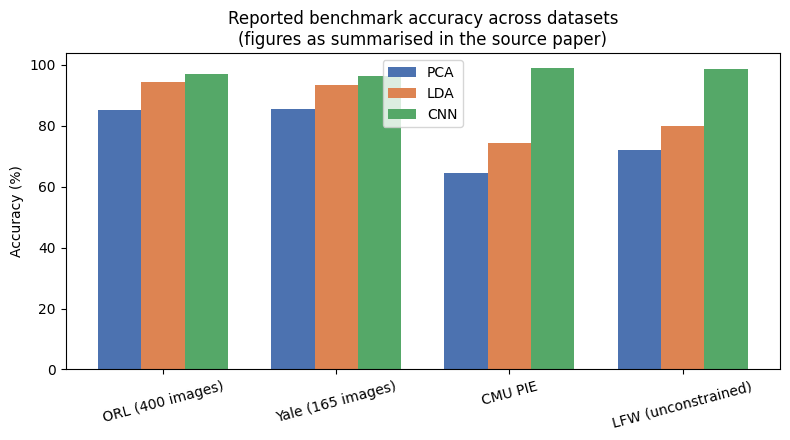

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(benchmark))
width = 0.25
ax.bar(x - width, benchmark["PCA accuracy (%)"], width, label="PCA", color="#4C72B0")
ax.bar(x, benchmark["LDA accuracy (%)"], width, label="LDA", color="#DD8452")
ax.bar(x + width, benchmark["CNN accuracy (%)"], width, label="CNN", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(benchmark["Dataset"], rotation=15)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Reported benchmark accuracy across datasets\n(figures as summarised in the source paper)")
ax.legend()
plt.tight_layout()
plt.show()


**Reading the table.** LDA consistently outperforms PCA by roughly 8–10 percentage points across controlled datasets (ORL, Yale, CMU PIE), which matches the qualitative result from our synthetic experiment. CNN-based methods dominate on unconstrained, in-the-wild data (LFW), because they can learn non-linear features that no linear projection — PCA or LDA — can represent.

## 7. When to Use Each Model

| Model | Best scenario | Strengths | Limitations |
|---|---|---|---|
| PCA | Small datasets, controlled environment, limited compute | Fast, unsupervised, interpretable eigenfaces | No class supervision; sensitive to illumination |
| LDA | Moderate labelled data, illumination/expression variation | Maximises class separation | Needs labels; $S_W$ singular when $d > n$ |
| CNN | Large-scale, unconstrained data, high accuracy required | End-to-end non-linear learning | Requires large data and GPU compute |
| SVM + LBP | Real-time, embedded systems | Low memory, texture-aware | Limited to local handcrafted features |


## 8. Discussion and Conclusion

PCA provides a strong unsupervised baseline, particularly when illumination is consistent across photographs. Its key limitation, illustrated directly in Figure 1, is that it retains the dimensions of maximum *total* variance — which may be dominated by lighting rather than identity. LDA addresses this by explicitly optimising class separability, at the cost of requiring labelled data and a PCA pre-reduction step whenever $d > n$.

For modern, unconstrained recognition problems — varying pose, crowded scenes, cross-age matching — convolutional neural networks dominate because they learn hierarchical, non-linear features directly from data. PCA and LDA nonetheless remain valuable: they are fast, require no GPU, are easy to interpret, and are often combined with deep embeddings or metric learning in lightweight production systems.

**Summary rule of thumb:** start with PCA for quick exploration and visualisation; move to LDA once labelled identities are available and illumination/expression is a concern; reserve CNNs for large-scale, unconstrained deployment.

## References

1. Turk, M. & Pentland, A. (1991). *Eigenfaces for Recognition.* Journal of Cognitive Neuroscience.
2. Belhumeur, P. N. et al. (1997). *Eigenfaces vs. Fisherfaces.* IEEE TPAMI, 19(7).
3. Fernandes, S. & Bala, J. (2013). *Performance Analysis of PCA-based and LDA-based Algorithms.* IJSPS.
4. Nemavhola, A. et al. (2025). *Systematic Review of CNN Architectures for Face Recognition.* Information, 16(2).
5. Singh, S. et al. (2018). *Techniques and Challenges of Face Recognition.* Procedia Computer Science.